In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import ok_netCDF as onc
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd() / "../local"))
import ok_local as okl

In [2]:

year=2026
month=6
day=8
hour=22

dataVolume=okl.get_local_dataVolume();
#tarFile="2026/2026-06/2026-06-08/level2/archive_2026-06-08T02"
dataDir=f"{year}/{year}-{month:02d}/{year}-{month:02d}-{day:02d}/level2/"
tarFile=f"archive_{year}-{month:02d}-{day:02d}T{hour:02d}.tar"

strDataSrc=f"{dataVolume}{dataDir}{tarFile}"
print(f"Combining netCDF files from tar file: {strDataSrc}")

combined_ds = onc.combine_nc_from_tar(strDataSrc);


Combining netCDF files from tar file: /Volumes/staff-umbrella/PARSAX Vadatech SkyTorque Data/2026/2026-06/2026-06-08/level2/archive_2026-06-08T22.tar
Detected 4 overlapping member time ranges in /Volumes/staff-umbrella/PARSAX Vadatech SkyTorque Data/2026/2026-06/2026-06-08/level2/archive_2026-06-08T22.tar:
  Overlap between ./level2_PARSAX_2026-06-08T22-15-00Z.nc [2026-06-08T22:15:00.000000000 - 2026-06-08T22:19:59.264331999] and ./level2_PARSAX_2026-06-08T22-19-59Z.nc [2026-06-08T22:19:59.000000000 - 2026-06-08T22:24:58.746577000]
  Overlap between ./level2_PARSAX_2026-06-08T22-25-00Z.nc [2026-06-08T22:25:00.000000000 - 2026-06-08T22:29:59.262229000] and ./level2_PARSAX_2026-06-08T22-29-59Z.nc [2026-06-08T22:29:59.000000000 - 2026-06-08T22:34:58.739038000]
  Overlap between ./level2_PARSAX_2026-06-08T22-35-00Z.nc [2026-06-08T22:35:00.000000000 - 2026-06-08T22:39:59.260312000] and ./level2_PARSAX_2026-06-08T22-39-59Z.nc [2026-06-08T22:39:59.000000000 - 2026-06-08T22:44:58.740848999]
  

In [3]:
with xr.set_options(display_max_rows=200, display_width=400):
    print(combined_ds)

<xarray.Dataset> Size: 7GB
Dimensions:                            (sweep: 1, time: 6319, range: 3000, altitude: 1, latitude: 1, longitude: 1)
Coordinates:
  * time                               (time) datetime64[ns] 51kB 2026-06-08T22:04:59 2026-06-08T22:04:59.508911 2026-06-08T22:05:00.079894 2026-06-08T22:05:00.589713999 2026-06-08T22:05:01.099716 2026-06-08T22:05:01.608292 ... 2026-06-08T22:59:56.160780 2026-06-08T22:59:56.670440 2026-06-08T22:59:57.179316999 2026-06-08T22:59:57.718820 2026-06-08T22:59:58.256817 2026-06-08T22:59:58.766864
    azimuth                            (time) float32 25kB 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 ... 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1
    elevation                          (time) float32 

In [4]:
'''
fig, ax = plt.subplots(figsize=(10, 6))
combined_ds["time"].plot(ax=ax)
ax.set_title("Time")
plt.show()
'''

'\nfig, ax = plt.subplots(figsize=(10, 6))\ncombined_ds["time"].plot(ax=ax)\nax.set_title("Time")\nplt.show()\n'

In [5]:
times = combined_ds['time'].values
import numpy as np
print("sorted?", np.all(np.diff(times) > np.timedelta64(0, 's')))

sorted? True


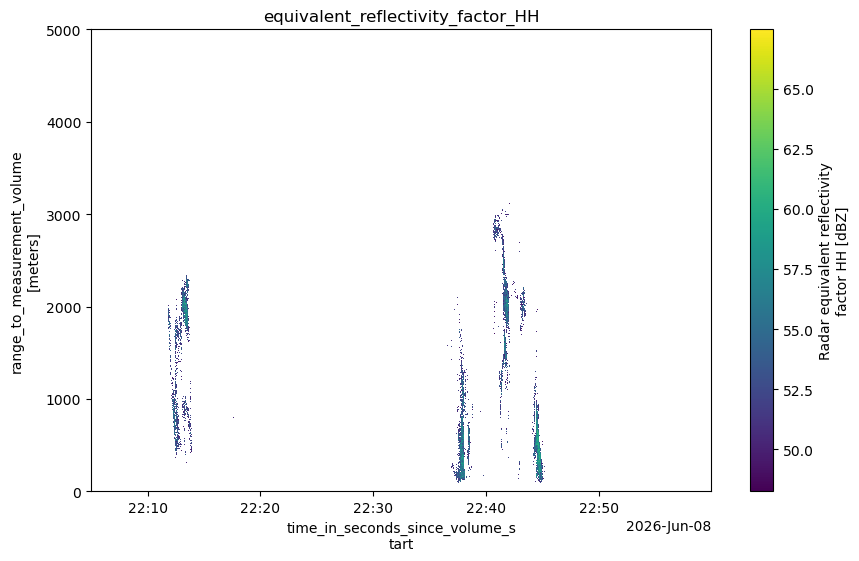

In [6]:
var_name='equivalent_reflectivity_factor_HH' #'rawreflectivity_HH' # 'ncp_HH'

fig, ax = plt.subplots(figsize=(10, 6))
combined_ds[var_name].T.plot(ax=ax, cmap="viridis")
ax.set_ylim(0, 5000)  # set vertical axis range
ax.set_title(var_name)
plt.show()

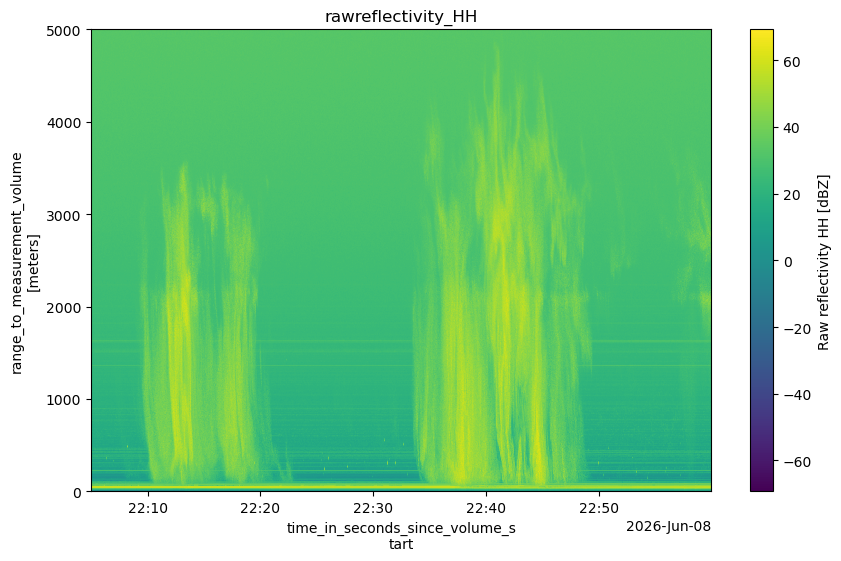

In [7]:
var_name='rawreflectivity_HH' # 'ncp_HH'

fig, ax = plt.subplots(figsize=(10, 6))
combined_ds[var_name].T.plot(ax=ax, cmap="viridis")
ax.set_ylim(0, 5000)  # set vertical axis range
ax.set_title(var_name)
plt.show()